<img src="images/array_print.png" alt="Array Print" align="right"/>

# Array Print

`arrayprint` takes a `.csv` containing a MITOMI-assayable library in a tabular format
and returns a Scienion-compatible `.fld` file and a `.csv` record of the array layout.

In [1]:
from string import ascii_uppercase
import itertools

import matplotlib.pyplot as plt
import pandas as pd

import arrayprint

pd.options.display.max_rows = 15
pd.options.display.max_columns = 15

# Create print plate

In [2]:
print_plate = pd.DataFrame(
    columns=range(1, 25), index=list(ascii_uppercase[:16])
)

for oligo, column in itertools.chain(
    zip(range(23, 34), range(1, 23, 2), strict=True),
    zip(range(34, 45), range(2, 24, 2), strict=True),
):
    for dilution, row in enumerate(ascii_uppercase[0:16:2], start=1):
        print_plate.loc[row, column] = f"{oligo}-{dilution}"

print_plate

,1,2,3,4,5,6,7,...,18,19,20,21,22,23,24
A,23-1,34-1,24-1,35-1,25-1,36-1,26-1,...,42-1,32-1,43-1,33-1,44-1,NaN,NaN
B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,23-2,34-2,24-2,35-2,25-2,36-2,26-2,...,42-2,32-2,43-2,33-2,44-2,NaN,NaN
D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,23-3,34-3,24-3,35-3,25-3,36-3,26-3,...,42-3,32-3,43-3,33-3,44-3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M,23-7,34-7,24-7,35-7,25-7,36-7,26-7,...,42-7,32-7,43-7,33-7,44-7,NaN,NaN
N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O,23-8,34-8,24-8,35-8,25-8,36-8,26-8,...,42-8,32-8,43-8,33-8,44-8,NaN,NaN


# Configure blocks
Create the print specification as dataframe with the following structure:
| Plate | Well            | Name | Block |
|-------|-----------------|------|-------|
| 1     | A1              | 23-1 | 1, 2  |

In [3]:
l = []

for col, series in print_plate.items():
    for row, val in series.items():
        if not pd.isna(val):
            l.append(
                {"Plate": 1, "Well": f"{row}{col}", "Name": val, "Block": (1,)}
            )

print_spec = pd.DataFrame(l)
print_spec

,Plate,Well,Name,Block
0,1,A1,23-1,"(1,)"
1,1,C1,23-2,"(1,)"
2,1,E1,23-3,"(1,)"
3,1,G1,23-4,"(1,)"
4,1,I1,23-5,"(1,)"
...,...,...,...,...
171,1,G22,44-4,"(1,)"
172,1,I22,44-5,"(1,)"
173,1,K22,44-6,"(1,)"
174,1,M22,44-7,"(1,)"


# Project Configuration
Set all project parameters, print settings, and file paths

In [4]:
project = "MyProject"

rows = 56
columns = 32
skip_rows = True
n_blocks = 1
device = "PS1.8K"

print(
    f"{rows * columns} chambers with {n_blocks} block{'s' if n_blocks > 1 else ''},"
    f" {int(rows * columns / n_blocks)} chambers per block"
)

1792 chambers with 1 block, 1792 chambers per block


# Generate print array

Generate print array, keeping the number of replicates roughly constant per variant.

In [5]:
print_array = arrayprint.generate_print_array(
    print_spec=print_spec,
    rows=rows,
    columns=columns,
    skip_rows=skip_rows,
    n_blocks=n_blocks,
    notch_column=28,
    notch_depth=20,
)

# Print metrics
Generate comprehensive metrics for the print array

In [6]:
metrics = arrayprint.get_print_metrics(print_array)
arrayprint.print_metrics_summary(metrics)

Total Variants       176
Array Positions     1792
Filled Positions     886
Blank Positions      906
Fill Rate           0.49
Mean Replicates     5.03
5 Replicates         170
6 Replicates           6


# Visualize the distribution of replicates

Visualize the frequency of single sequences across array to ensure even distribution and no dropouts

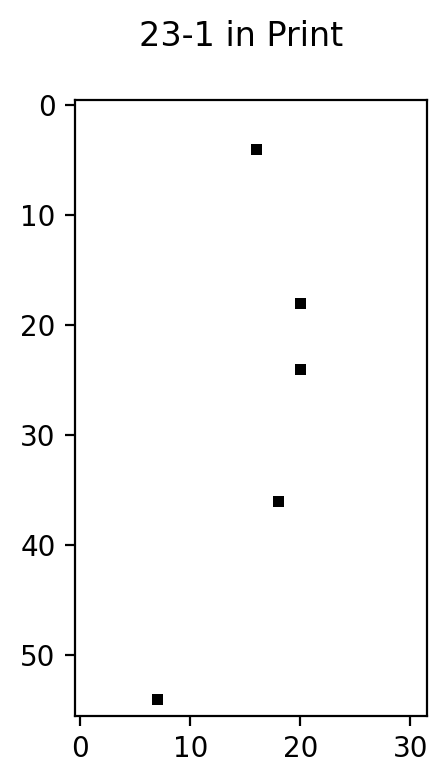

In [7]:
arrayprint.plot_mutant_position(print_array, print_spec, "23-1", n_blocks)
plt.show()

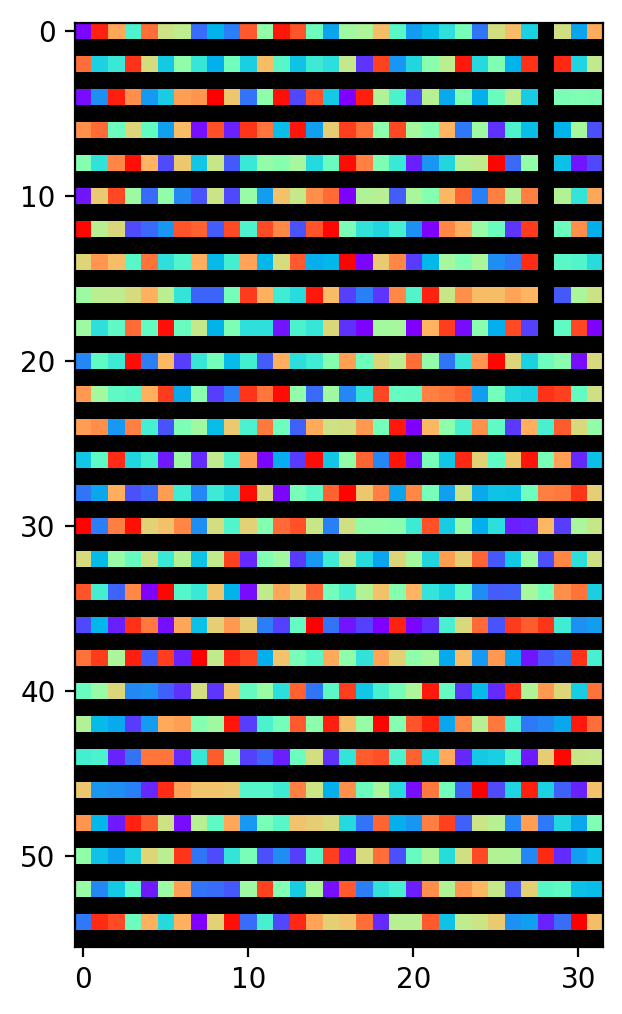

In [8]:
arrayprint.plot_array_heatmap(print_array)
plt.show()

# Save `.fld` file body in `.txt` output

Last, export this array to a fld file text output

In [9]:
arrayprint.write_fld(project, print_array, device=device)